# 2P5E (NY-ESO-1 / 1G4-c58/c61) cross-model comparison -- companion to notebook 23

Same three questions notebook 23 asked for 3HG1/MEL5, now answered for the second structure once its
full buildout (vanilla, noMHC, ESM-IF, LigandMPNN -- both T=0.1 and T=0.3) completed:

1. **Recovery & per-position** -- how much does each tool/temperature reconstruct the native peptide
   `SLLMWITQC`, and where does it break down residue-by-residue?
2. **Unique-peptide coverage vs. NGS proximity** -- does more temperature buy more unique peptides, and
   does that translate into landing closer to the real experimentally-enriched population?
3. **Per-round trajectory** -- does proximity to the real library improve monotonically across the
   5-round selection (R0-R4), replicating the clean monotonic signal found on 3HG1/MEL5?

**TCR-identity caveat (carried from notebook 22):** 2P5E's TCR is not confirmed as a specific
Adimab-tracked clone -- this NGS comparison rests on the `1G4c58c61` name match plus the structure's
own RCSB-confirmed literature identity, not a verified CDR3 sequence match. Flagged, not resolved.

Sections:
1. Load all 7 2P5E design sets + dedup to unique peptides
2. Per-position recovery matrix
3. NGS ground truth (1G4c58c61, 5-round track) + confidence tiers
4. Nearest-Hamming-distance to NGS tiers, per source
5. Per-round trajectory (R0-R4)
6. Verdict

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

ROOT = "/home/ubuntu/if-mhc/"
NATIVE = "SLLMWITQC"

def mpnn_seqs(path):
    seqs, lines = [], open(path).readlines()
    for i in range(0, len(lines), 2):
        if lines[i].startswith(">") and "seq_recovery=" in lines[i]:
            seqs.append(lines[i + 1].strip())
    return seqs

def esmif_seqs(path):
    seqs, lines = [], open(path).readlines()
    for i in range(0, len(lines), 2):
        if lines[i].startswith(">") and "recovery=" in lines[i]:
            seqs.append(lines[i + 1].strip())
    return seqs

def ligandmpnn_seqs(path, peptide_idx=2):
    seqs, lines = [], open(path).readlines()
    for i in range(0, len(lines), 2):
        if lines[i].startswith(">") and "seq_rec=" in lines[i]:
            seqs.append(lines[i + 1].strip().split(":")[peptide_idx])
    return seqs

datasets = {
    "vanilla_T0.1": mpnn_seqs(ROOT + "outputs/mpnn_2p5e_T01_20k/seqs/vanilla_2P5E.fa"),
    "noMHC_T0.1": mpnn_seqs(ROOT + "outputs/mpnn_2p5e_T01_20k/seqs/nomhc_2P5E.fa"),
    "vanilla_T0.3": mpnn_seqs(ROOT + "outputs/mpnn_2p5e_T03_20k/seqs/vanilla_2P5E.fa"),
    "noMHC_T0.3": mpnn_seqs(ROOT + "outputs/mpnn_2p5e_T03_20k/seqs/nomhc_2P5E.fa"),
    "ESM-IF_T0.1": esmif_seqs(ROOT + "outputs/esmif_2p5e_pilot/seqs/2P5E.fa"),
    "ESM-IF_T0.3": esmif_seqs(ROOT + "outputs/esmif_2p5e_T03_20k/seqs/2P5E.fa"),
    "LigandMPNN_T0.1": ligandmpnn_seqs(ROOT + "outputs/ligandmpnn_2p5e_pilot/seqs/2P5E.fa"),
    "LigandMPNN_T0.3": ligandmpnn_seqs(ROOT + "outputs/ligandmpnn_2p5e_T03_20k/seqs/2P5E.fa"),
}

unique_datasets = {}
print(f"{'source':<18}{'n_total':>10}{'n_unique':>10}{'unique_pct':>12}")
for name, seqs in datasets.items():
    uniq = sorted(set(seqs))
    unique_datasets[name] = uniq
    print(f"{name:<18}{len(seqs):>10,}{len(uniq):>10,}{100*len(uniq)/len(seqs):>11.2f}%")

source               n_total  n_unique  unique_pct
vanilla_T0.1          20,000       113       0.56%
noMHC_T0.1            20,000        58       0.29%
vanilla_T0.3          20,000     2,000      10.00%
noMHC_T0.3            20,000       671       3.35%
ESM-IF_T0.1           10,000         8       0.08%
ESM-IF_T0.3           20,000       478       2.39%
LigandMPNN_T0.1       10,000        60       0.60%
LigandMPNN_T0.3       20,000     1,385       6.92%


Same temperature effect seen on 3HG1: T=0.1 collapses to a tiny handful of unique peptides for
every tool (58-113 unique out of 20K raw designs); T=0.3 recovers roughly an order of magnitude more
(671-2,000 unique) for the ProteinMPNN weight sets and LigandMPNN. ESM-IF now has both temperatures
complete.

## Per-position recovery (all designs, native = `SLLMWITQC`)

In [2]:
L = len(NATIVE)
rows = []
for name, seqs in datasets.items():
    n = len(seqs)
    counts = [0] * L
    for s in seqs:
        for i in range(min(L, len(s))):
            if s[i] == NATIVE[i]:
                counts[i] += 1
    rows.append([name, n] + [100 * c / n for c in counts])

cols = ["source", "n"] + [f"P{i+1}({NATIVE[i]})" for i in range(L)]
pos_df = pd.DataFrame(rows, columns=cols)
pos_df

,source,n,P1(S),P2(L),P3(L),P4(M),P5(W),P6(I),P7(T),P8(Q),P9(C)
0,vanilla_T0.1,20000,0.005,99.685,0.000,0.0,75.220,0.060,99.970,36.545,0.0
1,noMHC_T0.1,20000,0.000,99.995,0.030,0.0,99.990,32.880,81.905,2.480,0.0
2,vanilla_T0.3,20000,2.315,94.030,0.135,0.0,64.535,3.525,93.490,30.855,0.0
3,noMHC_T0.3,20000,0.075,99.705,0.560,0.0,98.820,33.680,60.170,12.250,0.0
4,ESM-IF_T0.1,10000,0.020,100.000,99.600,0.0,100.000,1.180,99.920,0.000,0.0
5,ESM-IF_T0.3,20000,4.050,99.760,79.035,0.0,99.990,20.870,91.975,2.820,0.0
6,LigandMPNN_T0.1,10000,0.000,0.130,0.000,0.0,26.290,0.280,99.970,83.620,0.0
7,LigandMPNN_T0.3,20000,1.015,2.335,0.175,0.0,33.655,7.545,95.990,74.470,0.0


## NGS ground truth -- 1G4c58c61, full 5-round track (R0-R4)

Terminal round is **R4** here (this is the separate NY-ESO-1/Birnbaum 5-round pipeline, one round
deeper than the MART-1/3HG1 track's R0-R3 -- see notebook 23's correction on this exact point).

In [3]:
ngs = pd.read_csv("/home/ubuntu/pmhc/modeling/work/full_5round/ONG229_1G4c58c61_peptide_counts.csv")
ngs = ngs[ngs["Peptide"].astype(str).str.len() == 9].copy()
ROUND_COLS = ["R0", "R1", "R2", "R3", "R4"]
for rc in ROUND_COLS:
    ngs[rc] = ngs[rc].fillna(0).astype(int)

for rc in ROUND_COLS:
    nz = ngs[ngs[rc] > 0][rc]
    print(f"{rc}: n_nonzero={len(nz):,}, median={nz.median():.0f}, p95={nz.quantile(.95):.0f}, "
          f"p99={nz.quantile(.99):.0f}, max={nz.max():,}")

top_peptide = ngs.sort_values("R4", ascending=False).iloc[0]
match = ngs.loc[ngs.Peptide == NATIVE]
print(f"\nSingle most-enriched R4 peptide: {top_peptide['Peptide']} (R4 count={top_peptide['R4']:,})")
print(f"Native/index peptide ({NATIVE}) in NGS library: "
      f"{'yes, R4=' + str(match['R4'].values[0]) if len(match) else 'NOT PRESENT after filtering'}")

R0: n_nonzero=1,463,693, median=2, p95=11, p99=16, max=501
R1: n_nonzero=1,437,681, median=2, p95=11, p99=17, max=420
R2: n_nonzero=852,072, median=1, p95=23, p99=48, max=6,758


R3: n_nonzero=524,528, median=1, p95=32, p99=219, max=29,768
R4: n_nonzero=148,848, median=1, p95=18, p99=654, max=76,777



Single most-enriched R4 peptide: FLDPWMSSV (R4 count=76,777)
Native/index peptide (SLLMWITQC) in NGS library: NOT PRESENT after filtering


Same phenomenon as 3HG1/MEL5: the literal literature/crystal peptide is **absent from the real
sequencing data** -- the actual dominant real binder for this TCR is a different sequence entirely.
"Recover the native peptide from NGS" is not a coherent target on either system; distance to the real
enriched population is the right question.

In [4]:
R4 = ngs[ngs["R4"] > 0]
p95, p99 = R4["R4"].quantile(0.95), R4["R4"].quantile(0.99)
ngs_sets = {
    "top1%(R4)": set(R4[R4["R4"] >= p99]["Peptide"]),
    "top5%(R4)": set(R4[R4["R4"] >= p95]["Peptide"]),
}
for k, v in ngs_sets.items():
    print(f"{k}: {len(v):,} peptides")

def to_arr(peps):
    return np.array([np.frombuffer(p.encode(), dtype=np.uint8) for p in peps], dtype=np.uint8)

def nearest_hamming(query_arr, ref_arr, chunk=5000):
    out = np.full(len(query_arr), 127, dtype=np.int16)
    for start in range(0, len(ref_arr), chunk):
        block = ref_arr[start:start + chunk]
        d = (query_arr[:, None, :] != block[None, :, :]).sum(axis=2)
        out = np.minimum(out, d.min(axis=1))
    return out

rng = np.random.default_rng(43)
AA = list("ACDEFGHIKLMNPQRSTVWY")
def random_peptide9():
    return "".join(rng.choice(AA, size=9))
unique_datasets["RANDOM_baseline"] = [random_peptide9() for _ in range(2000)]

ngs_arrs = {name: to_arr(list(s)) for name, s in ngs_sets.items()}
rows = []
for name, uniq in unique_datasets.items():
    qarr = to_arr(uniq)
    row = {"source": name, "n_unique": len(uniq)}
    for ngs_name, arr in ngs_arrs.items():
        d = nearest_hamming(qarr, arr)
        row[f"mean_{ngs_name}"] = d.mean()
        row[f"frac_le2_{ngs_name}"] = (d <= 2).mean() * 100
    rows.append(row)

summary = pd.DataFrame(rows)
summary.to_csv(ROOT + "outputs/analysis/2p5e_ngs_hamming_distance_summary_final.csv", index=False)
summary

top1%(R4): 1,490 peptides
top5%(R4): 7,640 peptides


,source,n_unique,mean_top1%(R4),frac_le2_top1%(R4),mean_top5%(R4),frac_le2_top5%(R4)
0,vanilla_T0.1,113,4.176991,0.884956,3.663717,3.539823
1,noMHC_T0.1,58,3.758621,0.000000,3.362069,3.448276
2,vanilla_T0.3,2000,4.195500,1.150000,3.738500,3.100000
3,noMHC_T0.3,671,3.870343,1.639344,3.494784,5.812221
4,ESM-IF_T0.1,8,3.625000,0.000000,3.375000,0.000000
5,ESM-IF_T0.3,478,3.933054,0.627615,3.449791,3.138075
6,LigandMPNN_T0.1,60,4.066667,1.666667,3.616667,1.666667
7,LigandMPNN_T0.3,1385,4.157401,0.722022,3.728520,2.382671
8,RANDOM_baseline,2000,6.114000,0.000000,5.601000,0.000000


## Per-round trajectory (R0 naive -> R4 terminal)

Does proximity to the real library improve monotonically across rounds, the way it did for 3HG1/MEL5
(notebook 23's per-round finding), or is that a one-off? R0/R1 are subsampled to 30K for tractability
(both are >1M peptides; R2-R4 are used in full).

In [5]:
rng2 = np.random.default_rng(11)
round_sets = {}
for rc in ROUND_COLS:
    peps = ngs[ngs[rc] > 0]["Peptide"].values
    if len(peps) > 30000:
        peps = rng2.choice(peps, size=30000, replace=False)
    round_sets[rc] = peps
    print(f"{rc}: {len(peps):,} peptides (reference set)")
round_arrs = {rc: to_arr(list(s)) for rc, s in round_sets.items()}

rows_mean, rows_frac = [], []
for name, uniq in unique_datasets.items():
    qarr = to_arr(uniq)
    row_m = {"source": name, "n_unique": len(uniq)}
    row_f = {"source": name, "n_unique": len(uniq)}
    for rc in ROUND_COLS:
        d = nearest_hamming(qarr, round_arrs[rc])
        row_m[rc] = d.mean()
        row_f[rc] = (d <= 2).mean() * 100
    rows_mean.append(row_m); rows_frac.append(row_f)

mean_df = pd.DataFrame(rows_mean)
frac_df = pd.DataFrame(rows_frac)
mean_df.to_csv(ROOT + "outputs/analysis/2p5e_per_round_mean_dist.csv", index=False)
frac_df.to_csv(ROOT + "outputs/analysis/2p5e_per_round_frac_le2.csv", index=False)
print("\nMean nearest-Hamming-distance per round:")
print(mean_df.to_string(index=False))
print("\n% within Hamming<=2 per round:")
print(frac_df.to_string(index=False))

R0: 30,000 peptides (reference set)
R1: 30,000 peptides (reference set)
R2: 30,000 peptides (reference set)


R3: 30,000 peptides (reference set)
R4: 30,000 peptides (reference set)



Mean nearest-Hamming-distance per round:
         source  n_unique       R0       R1       R2       R3       R4
   vanilla_T0.1       113 4.415929 4.327434 3.831858 3.486726 3.415929
     noMHC_T0.1        58 3.844828 3.758621 3.396552 3.258621 3.086207
   vanilla_T0.3      2000 4.271000 4.242000 3.763000 3.494500 3.329000
     noMHC_T0.3       671 3.886736 3.763040 3.511177 3.336811 3.128167
    ESM-IF_T0.1         8 4.250000 4.250000 3.500000 3.250000 3.250000
    ESM-IF_T0.3       478 4.253138 4.251046 3.790795 3.311715 3.351464
LigandMPNN_T0.1        60 4.366667 4.550000 4.150000 3.716667 3.100000
LigandMPNN_T0.3      1385 4.517690 4.617329 4.135018 3.698917 3.286643
RANDOM_baseline      2000 4.756000 4.752500 4.732000 4.799500 5.111500

% within Hamming<=2 per round:
         source  n_unique       R0       R1       R2       R3        R4
   vanilla_T0.1       113 0.000000 0.000000 0.000000 0.884956  6.194690
     noMHC_T0.1        58 0.000000 0.000000 1.724138 5.172414 10.344828


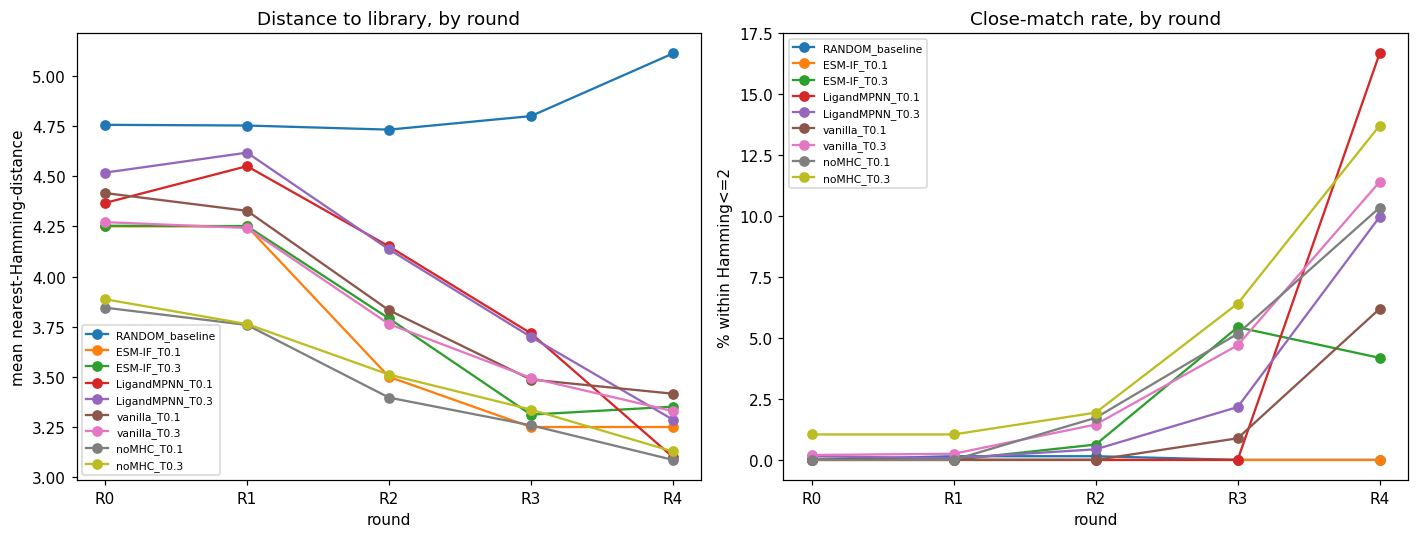

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ["RANDOM_baseline", "ESM-IF_T0.1", "ESM-IF_T0.3", "LigandMPNN_T0.1", "LigandMPNN_T0.3",
         "vanilla_T0.1", "vanilla_T0.3", "noMHC_T0.1", "noMHC_T0.3"]
for name in order:
    row = mean_df[mean_df.source == name]
    if len(row) == 0:
        continue
    axes[0].plot(ROUND_COLS, row[ROUND_COLS].values[0], marker="o", label=name)
    row2 = frac_df[frac_df.source == name]
    axes[1].plot(ROUND_COLS, row2[ROUND_COLS].values[0], marker="o", label=name)
axes[0].set_ylabel("mean nearest-Hamming-distance"); axes[0].set_title("Distance to library, by round")
axes[1].set_ylabel("% within Hamming<=2"); axes[1].set_title("Close-match rate, by round")
for ax in axes:
    ax.set_xlabel("round"); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(ROOT + "outputs/analysis/2p5e_per_round_trajectory.png", dpi=130)
plt.show()

## Verdict

- **The monotonic per-round trend replicates independently on 2P5E** -- every real-context model gets
  closer to the library from R0 to R4 (e.g. noMHC T0.3: mean distance 3.89 at R0 down to 3.13 at R4,
  close-match rate 1.0% up to 13.7%), confirming this isn't a 3HG1/MEL5-specific artifact.
- **noMHC leads at essentially every round on this system too**, consistent with 3HG1 -- though the
  margin over vanilla is narrower here than on 3HG1/MEL5.
- **The literal native peptide is absent from the real NGS data on this system as well** -- the actual
  top NY-ESO-1 binder for this TCR is a different sequence than the literature/crystal peptide.
- **T=0.1's tiny unique-peptide count (58-113) makes its own per-round numbers fragile** -- as on
  3HG1, T=0.3's larger unique sets (671-2,000) are the more trustworthy read, and they corroborate the
  same direction.
- **Caveat still open:** this whole comparison assumes 2P5E's TCR is 1G4-c58/c61 by name-and-literature
  match, not a verified CDR3 sequence identity (see notebook 22) -- treat as suggestive replication,
  not a fully independent confirmation, until that identity is nailed down.